# Notebook 4: ARIMAX and SARIMA Modeling

Two classical time series models:
- ARIMAX: ARIMA with exogenous Granger-selected macro variables
- SARIMA: Seasonal ARIMA via grid search

Train/test split: last 12 months held out as test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = {'EPU': '#2563EB', 'CPU': '#16A34A', 'GPR': '#DC2626'}

def mape(y_true, y_pred):
    return 100 * np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8)))

print('Libraries loaded.')

Libraries loaded.


In [3]:
# Load data
df      = pd.read_csv('../data/processed/df_transformed.csv', parse_dates=['Date'], index_col='Date')
df      = df.asfreq('MS')
granger = pd.read_excel('../data/processed/granger_causality_results.xlsx')
filtered= pd.read_excel('../data/processed/filtered_data.xlsx')
common_len = min(len(df), len(filtered))
df = df.iloc[:common_len]
filtered = filtered.iloc[:common_len]
filtered.index = df.index
HORIZON = 12
print(f'Data loaded. Shape: {df.shape}')

Data loaded. Shape: (434, 140)


## 1. ARIMAX — Auto Search with Exogenous Variables

In [4]:
def get_exog(target, granger_df, filtered_df, n=10):
    sig = granger_df[
        (granger_df['Target Variable'] == target) &
        (granger_df['Result'] == 'Significant')
    ].nsmallest(n, 'Min P-Value')
    features = [f for f in sig['Feature'].tolist() if f in filtered_df.columns]
    return filtered_df[features]

arimax_results = {}

for target in ['EPU', 'CPU', 'GPR']:
    print(f'\nBuilding ARIMAX for: {target}')
    series = df[target].dropna()
    exog   = get_exog(target, granger, filtered)
    min_len = min(len(series), len(exog))
    series  = series.iloc[:min_len]
    exog    = exog.iloc[:min_len]

    train_y, test_y = series[:-HORIZON], series[-HORIZON:]
    train_x, test_x = exog.iloc[:-HORIZON], exog.iloc[-HORIZON:]

    model = auto_arima(
        train_y, exogenous=train_x,
        seasonal=True, m=12,
        stepwise=True, information_criterion='aic',
        suppress_warnings=True, error_action='ignore'
    )
    print(f'Best order: {model.order}  seasonal: {model.seasonal_order}')

    forecast = model.predict(n_periods=HORIZON, exogenous=test_x)
    rmse = np.sqrt(mean_squared_error(test_y, forecast))
    mae  = mean_absolute_error(test_y, forecast)
    mape_val = mape(test_y.values, forecast)
    r2   = r2_score(test_y, forecast)

    arimax_results[target] = {
        'forecast': forecast, 'train_y': train_y, 'test_y': test_y,
        'RMSE': rmse, 'MAE': mae, 'MAPE': mape_val, 'R2': r2
    }
    print(f'RMSE={rmse:.2f}  MAE={mae:.2f}  MAPE={mape_val:.2f}%  R2={r2:.2f}')


Building ARIMAX for: EPU
Best order: (0, 1, 3)  seasonal: (2, 0, 1, 12)
RMSE=24.16  MAE=21.67  MAPE=11.68%  R2=-0.05

Building ARIMAX for: CPU
Best order: (3, 0, 1)  seasonal: (1, 0, 1, 12)
RMSE=58.71  MAE=45.14  MAPE=135.60%  R2=0.03

Building ARIMAX for: GPR
Best order: (1, 0, 2)  seasonal: (0, 0, 0, 12)
RMSE=11.37  MAE=8.46  MAPE=6.74%  R2=0.10


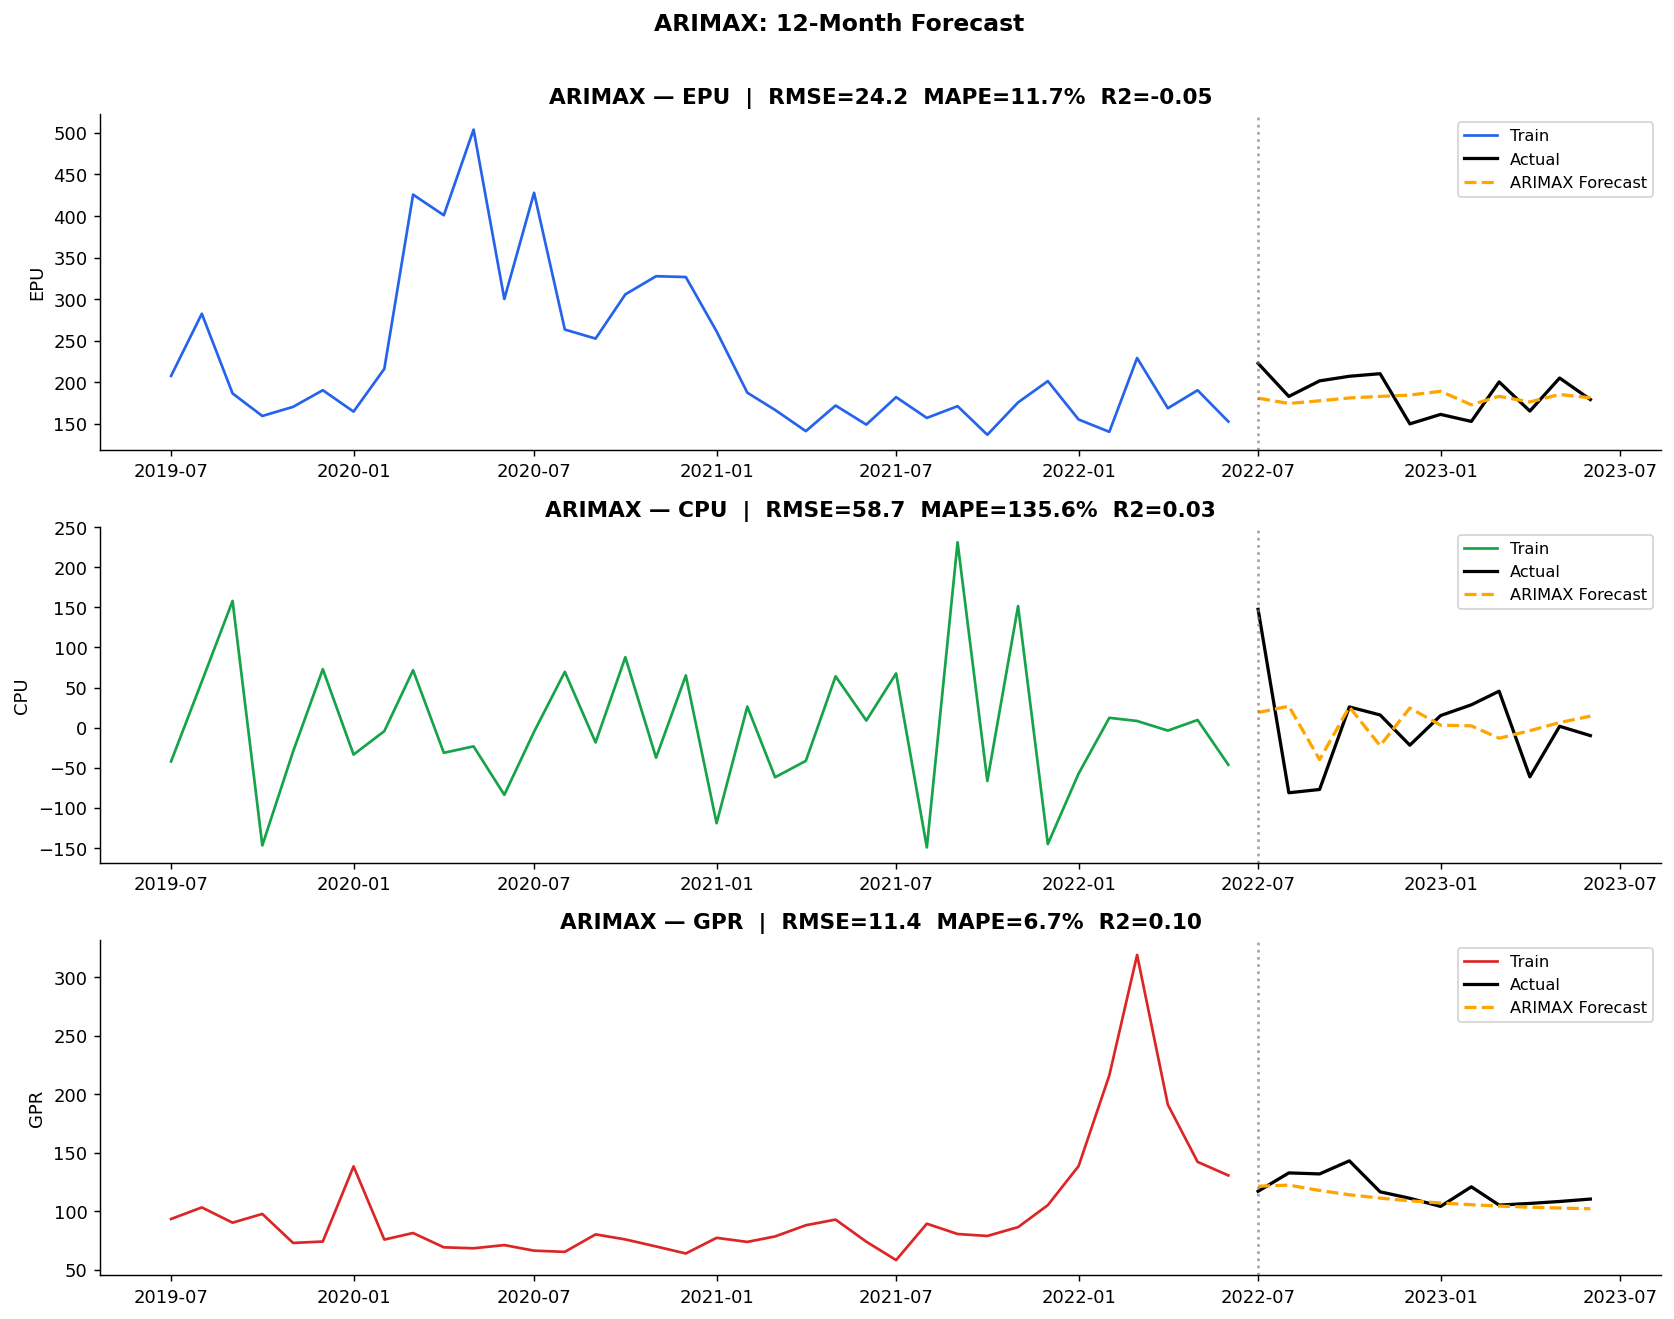

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))
for ax, target in zip(axes, ['EPU', 'CPU', 'GPR']):
    res = arimax_results[target]
    train_y, test_y = res['train_y'], res['test_y']
    forecast = pd.Series(res['forecast'], index=test_y.index)
    ax.plot(train_y.index[-36:], train_y.values[-36:], color=COLORS[target], linewidth=1.5, label='Train')
    ax.plot(test_y.index, test_y.values, color='black', linewidth=1.8, label='Actual')
    ax.plot(forecast.index, forecast.values, color='orange', linewidth=1.8, linestyle='--', label='ARIMAX Forecast')
    ax.axvline(test_y.index[0], color='gray', linestyle=':', alpha=0.7)
    metrics = f"RMSE={res['RMSE']:.1f}  MAPE={res['MAPE']:.1f}%  R2={res['R2']:.2f}"
    ax.set_title(f'ARIMAX — {target}  |  {metrics}', fontweight='bold')
    ax.set_ylabel(target)
    ax.legend(fontsize=9)
plt.suptitle('ARIMAX: 12-Month Forecast', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/11_arimax_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. SARIMA — Grid Search

In [6]:
param_grid = list(product(range(0,3), range(0,2), range(0,3), range(0,2), range(0,2), range(0,2)))
print(f'Total combinations: {len(param_grid)}')
sarima_results = {}

for target in ['EPU', 'CPU', 'GPR']:
    print(f'\nGrid searching SARIMA for {target}...')
    series = df[target].dropna()
    train, test = series[:-HORIZON], series[-HORIZON:]
    best_rmse, best_params, best_model, best_forecast = np.inf, None, None, None

    for params in param_grid:
        p, d, q, P, D, Q = params
        try:
            model = SARIMAX(train, order=(p,d,q), seasonal_order=(P,D,Q,12),
                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            forecast = model.forecast(steps=HORIZON)
            rmse = np.sqrt(mean_squared_error(test, forecast))
            if rmse < best_rmse:
                best_rmse, best_params, best_model, best_forecast = rmse, params, model, forecast
        except Exception:
            continue

    mae_val  = mean_absolute_error(test, best_forecast)
    mape_val = mape(test.values, best_forecast.values)
    r2_val   = r2_score(test, best_forecast)
    sarima_results[target] = {
        'params': best_params, 'forecast': best_forecast, 'train': train, 'test': test,
        'RMSE': best_rmse, 'MAE': mae_val, 'MAPE': mape_val, 'R2': r2_val
    }
    print(f'Best params: {best_params}  RMSE={best_rmse:.2f}  MAPE={mape_val:.2f}%  R2={r2_val:.2f}')

Total combinations: 144

Grid searching SARIMA for EPU...
Best params: (0, 0, 0, 1, 0, 1)  RMSE=23.18  MAPE=10.11%  R2=0.04

Grid searching SARIMA for CPU...
Best params: (0, 1, 2, 0, 0, 0)  RMSE=52.75  MAPE=95.98%  R2=0.22

Grid searching SARIMA for GPR...
Best params: (2, 0, 2, 0, 1, 1)  RMSE=9.81  MAPE=6.56%  R2=0.33


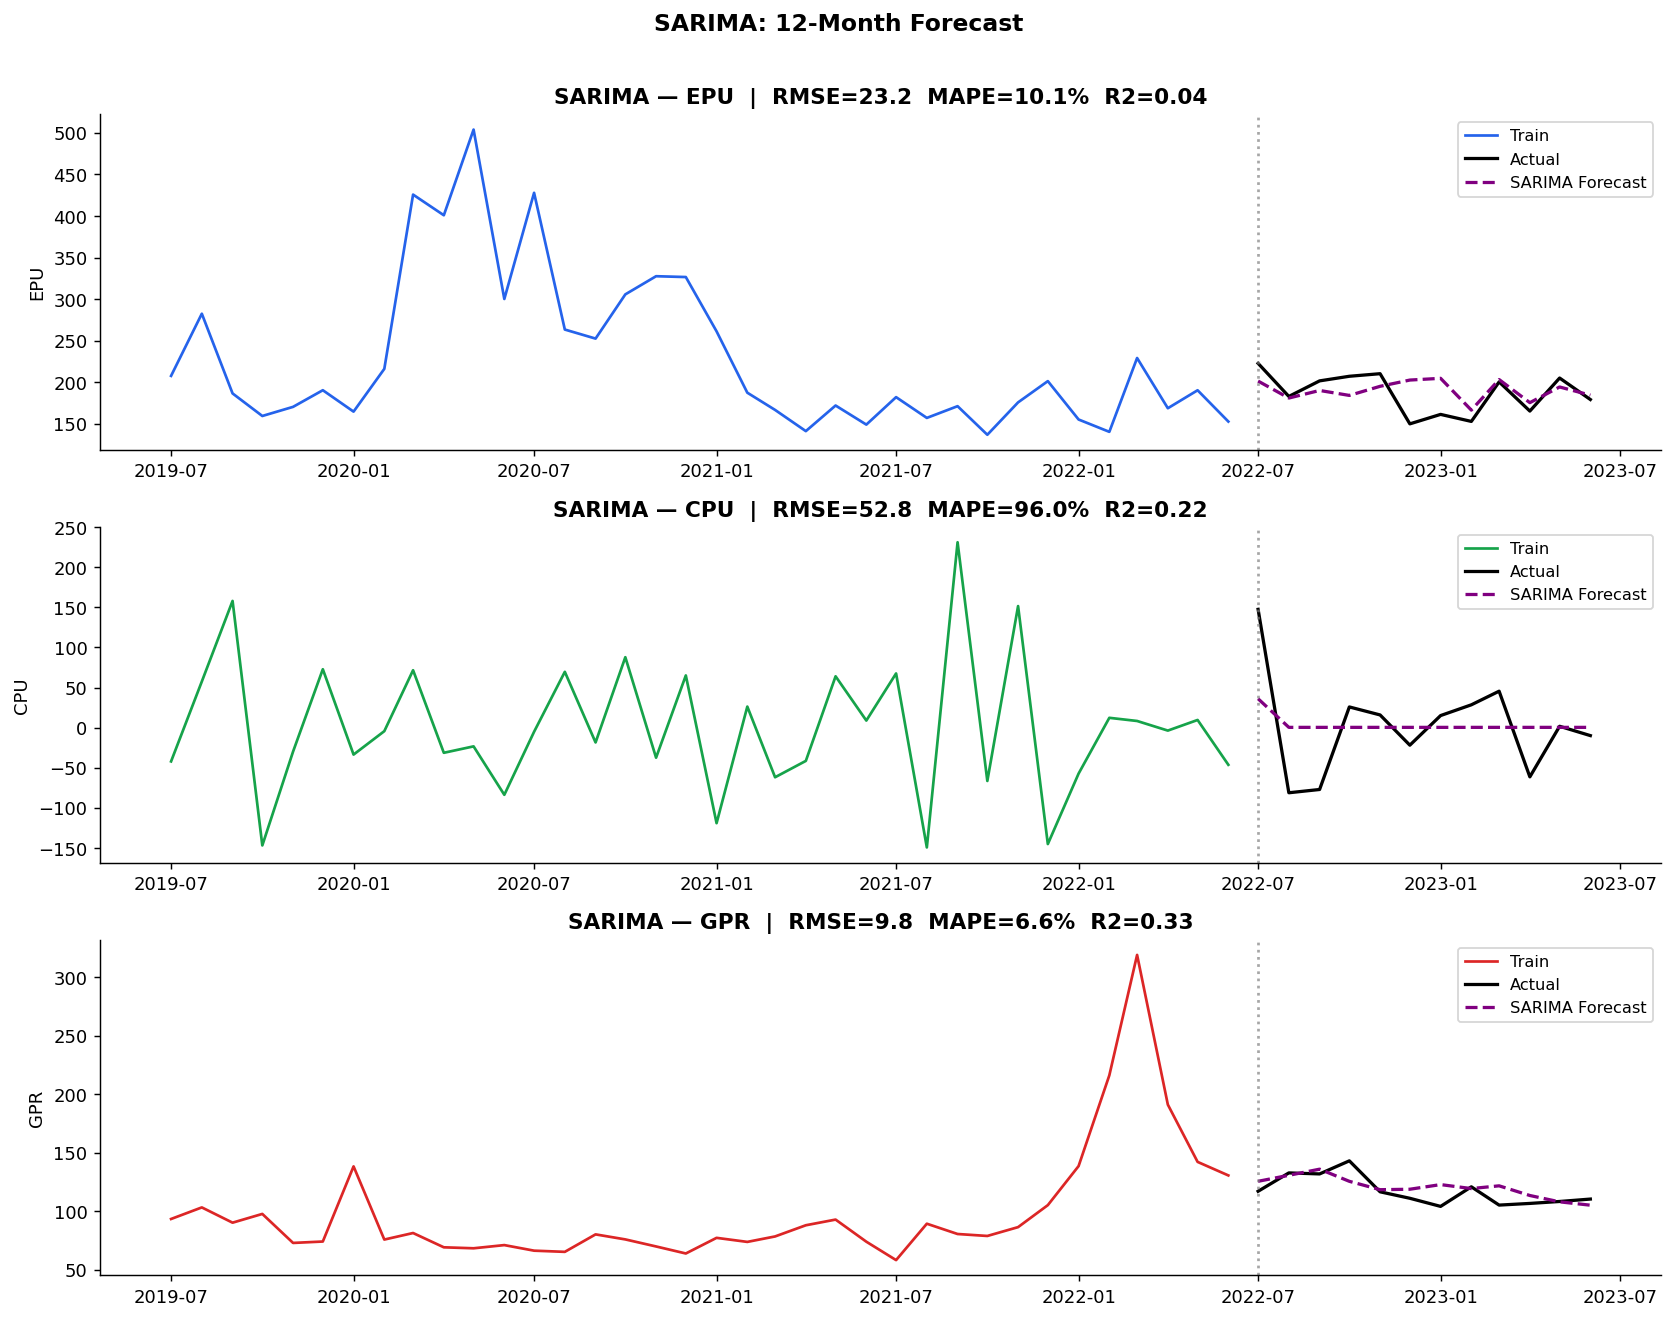

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))
for ax, target in zip(axes, ['EPU', 'CPU', 'GPR']):
    res = sarima_results[target]
    train, test = res['train'], res['test']
    forecast = pd.Series(res['forecast'].values, index=test.index)
    ax.plot(train.index[-36:], train.values[-36:], color=COLORS[target], linewidth=1.5, label='Train')
    ax.plot(test.index, test.values, color='black', linewidth=1.8, label='Actual')
    ax.plot(forecast.index, forecast.values, color='purple', linewidth=1.8, linestyle='--', label='SARIMA Forecast')
    ax.axvline(test.index[0], color='gray', linestyle=':', alpha=0.7)
    metrics = f"RMSE={res['RMSE']:.1f}  MAPE={res['MAPE']:.1f}%  R2={res['R2']:.2f}"
    ax.set_title(f'SARIMA — {target}  |  {metrics}', fontweight='bold')
    ax.set_ylabel(target)
    ax.legend(fontsize=9)
plt.suptitle('SARIMA: 12-Month Forecast', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/12_sarima_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Model Comparison

In [8]:
rows = []
for target in ['EPU', 'CPU', 'GPR']:
    for model_name, results_dict in [('ARIMAX', arimax_results), ('SARIMA', sarima_results)]:
        r = results_dict[target]
        rows.append({'Model': model_name, 'Target': target,
                     'RMSE': round(r['RMSE'],2), 'MAE': round(r['MAE'],2),
                     'MAPE': round(r['MAPE'],2), 'R2': round(r['R2'],3)})
comparison_df = pd.DataFrame(rows)
comparison_df.to_csv('../outputs/model_comparison.csv', index=False)
print(comparison_df.to_string(index=False))

 Model Target  RMSE   MAE   MAPE     R2
ARIMAX    EPU 24.16 21.67  11.68 -0.047
SARIMA    EPU 23.18 17.64  10.11  0.036
ARIMAX    CPU 58.71 45.14 135.60  0.028
SARIMA    CPU 52.75 41.23  95.98  0.215
ARIMAX    GPR 11.37  8.46   6.74  0.100
SARIMA    GPR  9.81  7.54   6.56  0.330


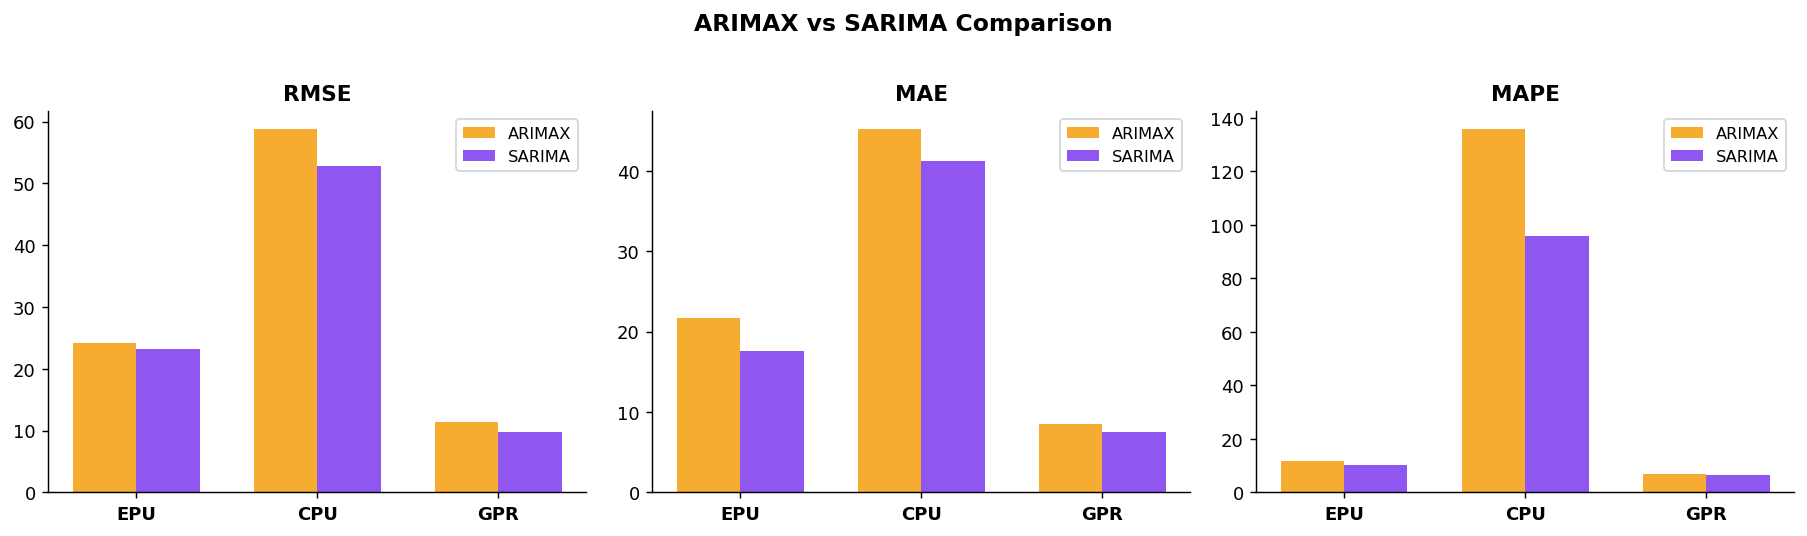

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
targets = ['EPU', 'CPU', 'GPR']
x = np.arange(len(targets))
width = 0.35
for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE']):
    arimax_vals = [comparison_df[(comparison_df['Model']=='ARIMAX')&(comparison_df['Target']==t)][metric].values[0] for t in targets]
    sarima_vals = [comparison_df[(comparison_df['Model']=='SARIMA')&(comparison_df['Target']==t)][metric].values[0] for t in targets]
    ax.bar(x-width/2, arimax_vals, width, label='ARIMAX', color='#F59E0B', alpha=0.85)
    ax.bar(x+width/2, sarima_vals, width, label='SARIMA', color='#7C3AED', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(targets, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.legend(fontsize=9)
plt.suptitle('ARIMAX vs SARIMA Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/13_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()